# Sentinel Flood Vision - EuroSAT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact, IntSlider

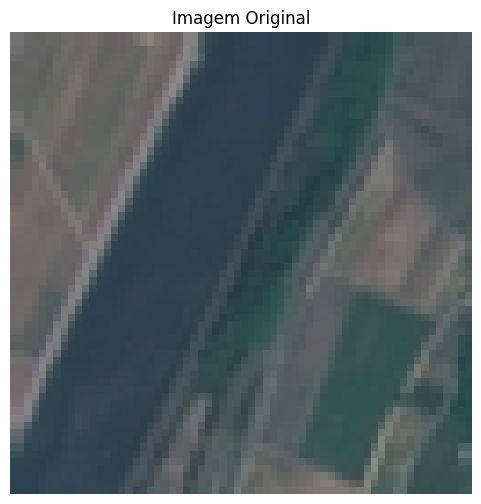

In [3]:
IMAGE_PATH = "/content/drive/MyDrive/EuroSAT_RGB/River/River_1.jpg"

img = cv2.imread(IMAGE_PATH)

if img is None:
    raise Exception(
        f"Imagem não encontrada: {IMAGE_PATH}"
    )

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Imagem Original")
plt.show()

In [4]:
def analisar_rio(
    h_min,
    h_max,
    s_min,
    v_min,
    kernel_size,
    dilatacao
):

    # ======================
    # DETECÇÃO DO RIO
    # ======================

    hsv = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2HSV
    )

    lower = np.array([
        h_min,
        s_min,
        v_min
    ])

    upper = np.array([
        h_max,
        255,
        255
    ])

    water_mask = cv2.inRange(
        hsv,
        lower,
        upper
    )

    # ======================
    # MORFOLOGIA
    # ======================

    kernel = np.ones(
        (kernel_size, kernel_size),
        np.uint8
    )

    water_mask = cv2.morphologyEx(
        water_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    water_mask = cv2.morphologyEx(
        water_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # ======================
    # MARGENS DO RIO
    # ======================

    contours, _ = cv2.findContours(
        water_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    border_img = img_rgb.copy()

    cv2.drawContours(
        border_img,
        contours,
        -1,
        (255,0,0),
        2
    )

    # ======================
    # ÁREA ORIGINAL
    # ======================

    original_area = cv2.countNonZero(
        water_mask
    )

    # ======================
    # EXPANSÃO DO RIO
    # ======================

    expanded_water = cv2.dilate(
        water_mask,
        kernel,
        iterations=dilatacao
    )

    expanded_area = cv2.countNonZero(
        expanded_water
    )

    # ======================
    # CRESCIMENTO
    # ======================

    if original_area == 0:

        growth = 0

    else:

        growth = (
            expanded_area -
            original_area
        ) / original_area * 100

    # ======================
    # CLASSIFICAÇÃO
    # ======================

    if growth < 40:

        status = "BAIXO"

    elif growth < 80:

        status = "MEDIO"

    else:

        status = "ALTO"

    # ======================
    # OVERLAY
    # ======================

    overlay = img_rgb.copy()

    # área expandida
    overlay[
        expanded_water > 0
    ] = [255,0,0]

    # rio original
    overlay[
        water_mask > 0
    ] = [0,255,255]

    # ======================
    # RESULTADO
    # ======================

    plt.figure(figsize=(25,5))

    plt.subplot(1,5,1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(
        water_mask,
        cmap="gray"
    )
    plt.title("Rio")
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(border_img)
    plt.title("Margens")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.imshow(
        expanded_water,
        cmap="gray"
    )
    plt.title(
        f"Cheia ({dilatacao})"
    )
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(overlay)
    plt.title(
        f"Risco {status}"
    )
    plt.axis("off")

    plt.show()

    print(
        f"Área Original: {original_area}"
    )

    print(
        f"Área Expandida: {expanded_area}"
    )

    print(
        f"Crescimento: {growth:.2f}%"
    )

    print(
        f"Classificação: {status}"
    )

In [6]:
interact(

    analisar_rio,

    h_min=IntSlider(
        min=0,
        max=179,
        value=90,
        description="H Min"
    ),

    h_max=IntSlider(
        min=0,
        max=179,
        value=140,
        description="H Max"
    ),

    s_min=IntSlider(
        min=0,
        max=255,
        value=95,
        description="S Min"
    ),

    v_min=IntSlider(
        min=0,
        max=255,
        value=75,
        description="V Min"
    ),

    kernel_size=IntSlider(
        min=1,
        max=25,
        step=2,
        value=5,
        description="Kernel"
    ),

    dilatacao=IntSlider(
        min=1,
        max=5,
        value=1,
        description="Cheia"
    )
)

interactive(children=(IntSlider(value=90, description='H Min', max=179), IntSlider(value=140, description='H M…

<function __main__.analisar_rio(h_min, h_max, s_min, v_min, kernel_size, dilatacao)>